In [1]:
import sys
sys.path.append("..")
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML, display
from pathlib import Path
from datasets import load_from_disk
from tqdm import tqdm
from sklearn.tree import plot_tree
import json
from rulefit import RuleFit

from src.data import PROJECT_ROOT
from src.llm_upgrade import wrap_for_transformer_lens
from src.sae import TopKSAE
from src.rule_extraction import (
    compute_sae_activations,
    compute_dt_fidelity,
    compute_best_single_rule,
    compute_union_coverage,
    rank_features_by_logic,
    generate_threshold_rules,
    extract_semantic_annotations,
    visualize_token_attributions,
    integrated_gradients_latent
)

In [2]:
EXP_ID = "exp7-2"
MODEL_NAME = "gpt2-large"
VARIANT = "depth-1"
ADAPTER_PATH = str(PROJECT_ROOT / f"results/checkpoints/finetune/{EXP_ID}/checkpoint-4000")
PROBING_JSON = PROJECT_ROOT / "results/probing/probe_gpt2-large(seq_QLoRA)_depth-1_resid_post_last.json"
with open(PROBING_JSON, "r", encoding="utf-8") as f:
    probing_data = json.load(f)
BEST_LAYER = probing_data["summary"]["best_layer"]
SAE_DIR = PROJECT_ROOT / f"results/sae/{EXP_ID}/layer_{BEST_LAYER}"
SAE_PATH = str(SAE_DIR / "sae_final.pt")

In [3]:
BASELINE_DIR = PROJECT_ROOT / "results/baselines" / EXP_ID
BASELINE_CACHE_DIR = BASELINE_DIR / "cache"

K_CANDIDATES = [50, 100, 200, 500]
CANDIDATE_POOL_K = 50
MAX_DEPTH = 3

In [4]:
torch.cuda.empty_cache()

# Загрузка модели, датасета и SAE

In [5]:
hooked_model, tokenizer = wrap_for_transformer_lens(MODEL_NAME, ADAPTER_PATH, device="cuda")
hooked_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\peft\tuners\lora\layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Loaded pretrained model gpt2-large into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-35): 36 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (hook_re

In [6]:
cache_path = PROJECT_ROOT / "data" / "processed" / f"ruletaker_{VARIANT}"
full_test = load_from_disk(str(cache_path))["test"]

In [7]:
checkpoint = torch.load(SAE_PATH, map_location="cuda", weights_only=False)
K_SAE_CFG = checkpoint['config']['k']
D_SAE = checkpoint['config']['d_sae']
D_MODEL = checkpoint['config']['d_in']

In [8]:
sae = TopKSAE(d_in=D_MODEL, d_sae=D_SAE, k=K_SAE_CFG).to("cuda")
sae.load_state_dict(checkpoint["model_state_dict"])
sae.eval()

TopKSAE()

In [9]:
activations, labels = compute_sae_activations(
    hooked_model=hooked_model, sae=sae, tokenizer=tokenizer,
    dataset=full_test, layer_idx=BEST_LAYER, max_samples=2000, device="cuda", use_eval_prefix=True
)
np.save(SAE_DIR / "test_activations_formatted.npy", activations)
np.save(SAE_DIR / "test_labels_formatted.npy", labels)

Вычисление активаций SAE: 100%|██████████| 2000/2000 [03:10<00:00, 10.51it/s]


In [10]:
activations = np.load(SAE_DIR / "test_activations_formatted.npy")
labels = np.load(SAE_DIR / "test_labels_formatted.npy")
llm_preds = torch.load(BASELINE_CACHE_DIR / "test_acts_preds.pt", map_location="cpu", weights_only=False)["preds"].numpy()
print(f"Активации загружены: {activations.shape}, Метки: {labels.shape}")

Активации загружены: (2000, 8192), Метки: (2000,)


In [11]:
sparsity_per_feature = np.mean(activations != 0, axis=0)
dead = np.sum(sparsity_per_feature < 1e-6)
print(f"Dead features: {dead}/{D_SAE} ({100*dead/D_SAE:.1f}%)")

Dead features: 8023/8192 (97.9%)


# Ранжирование признаков и генерация правил

In [12]:
# активации вычислены с eval_prefix
eval_prefix = "{theory} {assertion} The assertion is"
def format_text_for_logic(item):
    if "theory" in item and "assertion" in item:
        return eval_prefix.format(theory=item["theory"], assertion=item["assertion"])
    return item.get("text", "")

In [13]:
dataset_texts_formatted = [format_text_for_logic(full_test[i]) for i in range(len(labels))]

In [14]:
# разделение train/test для генерации и оценки правил (контроль data leakage)
rng = np.random.default_rng(42)
indices = rng.permutation(len(activations))
n = len(activations)
split = n // 2

act_tr, act_te = activations[indices[:split]], activations[indices[split:]]
labels_tr, labels_te = labels[indices[:split]], labels[indices[split:]]
llm_tr, llm_te = llm_preds[indices[:split]], llm_preds[indices[split:]]
texts_tr = [dataset_texts_formatted[i] for i in indices[:split]]

In [15]:
# Предварительное ранжирование и генерация правил (строго на train)
top_feat, corr_label, corr_logic, combined = rank_features_by_logic(act_tr, llm_tr, texts_tr)

In [16]:
for i, idx in enumerate(top_feat[:10]):
    print(f"  {i}. Feature #{idx}: corr(llm)={corr_label[idx]:+.3f}, corr(logic)={corr_logic[idx]:+.3f}")

rules_candidates = generate_threshold_rules(act_tr, llm_tr, corr_label, top_feat, top_k=CANDIDATE_POOL_K)

  0. Feature #524: corr(llm)=+0.334, corr(logic)=-0.162
  1. Feature #6312: corr(llm)=+0.425, corr(logic)=-0.113
  2. Feature #5209: corr(llm)=-0.304, corr(logic)=-0.138
  3. Feature #3889: corr(llm)=-0.555, corr(logic)=-0.071
  4. Feature #6910: corr(llm)=+0.272, corr(logic)=+0.101
  5. Feature #3166: corr(llm)=+0.365, corr(logic)=-0.067
  6. Feature #5328: corr(llm)=+0.169, corr(logic)=-0.126
  7. Feature #5907: corr(llm)=+0.263, corr(logic)=+0.076
  8. Feature #8143: corr(llm)=-0.109, corr(logic)=+0.169
  9. Feature #2340: corr(llm)=-0.152, corr(logic)=-0.114


# Построение моделей на правилах

## SAE + DT (сравнение с baseline)

In [17]:
sae_dt_results = []
for k in K_CANDIDATES:
    fid, acc, dt_mod = compute_dt_fidelity(act_te, act_tr, llm_te, llm_tr, labels_te, corr_label, k=k, max_depth=MAX_DEPTH)
    sae_dt_results.append({"K": k, "fidelity": round(fid, 4), "accuracy": round(acc, 4), "model": dt_mod})
    print(f"SAE+DT | K={k:4d} | Fidelity vs LLM: {fid:.4f} | Accuracy vs GT: {acc:.4f}")

SAE+DT | K=  50 | Fidelity vs LLM: 0.9300 | Accuracy vs GT: 0.7630
SAE+DT | K= 100 | Fidelity vs LLM: 0.9300 | Accuracy vs GT: 0.7630
SAE+DT | K= 200 | Fidelity vs LLM: 0.9300 | Accuracy vs GT: 0.7630
SAE+DT | K= 500 | Fidelity vs LLM: 0.9300 | Accuracy vs GT: 0.7630


## Best Single Rule (оценка на test)

In [18]:
best_fid, best_rule_info = compute_best_single_rule(
    act_te, act_tr, llm_te, llm_tr, corr_label, top_k_search=200
)

fid = best_rule_info["feature_id"]
thr = best_rule_info["threshold"]
corr = best_rule_info["corr"]

preds_gt = (act_te[:, fid] > thr).astype(int)
if corr <= 0:
    preds_gt = 1 - preds_gt
best_acc = float(np.mean(preds_gt == labels_te))

print(f"Fidelity vs LLM: {best_fid:.4f} | Accuracy vs GT: {best_acc:.4f} | Feature #{fid}")

Fidelity vs LLM: 0.8360 | Accuracy vs GT: 0.6430 | Feature #3889


c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Пороговые правила SAE (Union Coverage (оценка на test))

In [19]:
union_cov_llm, num_passed_rules = compute_union_coverage(
    act_te, act_tr, llm_te, llm_tr, corr_label, k=CANDIDATE_POOL_K, min_cov=0.01, min_acc=0.60
)
print(f"Прошло фильтр: {num_passed_rules} из {CANDIDATE_POOL_K}")
print(f"Union Coverage vs LLM: {union_cov_llm:.4f}")

Прошло фильтр: 32 из 50
Union Coverage vs LLM: 1.0000


# Результаты

In [20]:
combined_rows = []

In [21]:
baseline_json_path = BASELINE_DIR / "comparison_table_clean.json"
with open(baseline_json_path, "r", encoding="utf-8") as f:
    baseline_rows = json.load(f)
combined_rows.extend(baseline_rows)

In [22]:
for res in sae_dt_results:
    combined_rows.append({
        "Method": "SAE", "Mode": "Decision Tree", "K": res["K"],
        "Fidelity_vs_LLM": res["fidelity"], "Accuracy_vs_GT": res["accuracy"],
        "Union_Coverage_vs_LLM": round(union_cov_llm, 4),
        "Notes": "Единая модель на латентах"
    })

In [23]:
combined_rows.append({
    "Method": "SAE", "Mode": "Best Single Rule", "K": None,
    "Fidelity_vs_LLM": round(best_fid, 4), "Accuracy_vs_GT": round(best_acc, 4),
    "Union_Coverage_vs_LLM": None,
    "Notes": "Одно пороговое правило"
})

In [24]:
combined_rows.append({
    "Method": "SAE", "Mode": "Rules (Union)", "K": CANDIDATE_POOL_K,
    "Fidelity_vs_LLM": None, "Accuracy_vs_GT": None,
    "Union_Coverage_vs_LLM": round(union_cov_llm, 4),
    "Notes": f"OR-ансамбль: {num_passed_rules} правил прошло фильтр"
})

In [25]:
df_combined = pd.DataFrame(combined_rows)
df_combined.to_csv(BASELINE_DIR / "final_comparison_table.csv", index=False)
df_combined.to_json(BASELINE_DIR / "final_comparison_table.json", orient="records", indent=2)

In [26]:
df_combined

,Method,Mode,K,Fidelity_vs_LLM,Accuracy_vs_GT,Union_Coverage_vs_LLM,Notes
0,Gradient Importance,Decision Tree,50.0,0.328,0.479,1.0,Единая суррогатная модель
1,Gradient Importance,Decision Tree,100.0,0.321,0.472,1.0,Единая суррогатная модель
2,Gradient Importance,Decision Tree,200.0,0.689,0.506,1.0,Единая суррогатная модель
3,Gradient Importance,Decision Tree,500.0,0.702,0.519,1.0,Единая суррогатная модель
4,Gradient Importance,Best Single Rule,NaN,0.690,0.507,NaN,Одно пороговое правило
5,SHAP (Linear),Decision Tree,50.0,0.697,0.514,1.0,Единая суррогатная модель
6,SHAP (Linear),Decision Tree,100.0,0.696,0.513,1.0,Единая суррогатная модель
7,SHAP (Linear),Decision Tree,200.0,0.780,0.597,1.0,Единая суррогатная модель
8,SHAP (Linear),Decision Tree,500.0,0.720,0.537,1.0,Единая суррогатная модель
9,SHAP (Linear),Best Single Rule,NaN,0.690,0.507,NaN,Одно пороговое правило


# Визуализации

In [27]:
passed_rules_df = pd.DataFrame(rules_candidates)
passed_rules_df = passed_rules_df[(passed_rules_df["coverage"] >= 0.01) & (passed_rules_df["rule_accuracy"] >= 0.60)]

passed_rules_df["utility_score"] = passed_rules_df["rule_accuracy"] * passed_rules_df["coverage"]
passed_rules_df = passed_rules_df.sort_values("utility_score", ascending=False).reset_index(drop=True)

styled_df = passed_rules_df.style.background_gradient(
    subset=['coverage', 'rule_accuracy', 'utility_score'],
    cmap='YlOrRd', vmin=0, vmax=1)\
    .format(precision=3)\
    .set_caption(f"Правила, прошедшие фильтрацию ({len(passed_rules_df)} шт., отсортированы по полезности = acc × cov)")
display(styled_df)

,feature_id,threshold,corr_with_label,predicted_class,rule_accuracy,coverage,utility_score
0,524,10.139,0.334,1,0.613,0.396,0.243
1,5209,5.192,-0.304,0,0.681,0.294,0.200
2,6312,18.019,0.425,1,0.629,0.308,0.194
3,5771,11.188,-0.285,0,0.689,0.270,0.186
4,7647,7.967,-0.427,0,0.719,0.256,0.184
5,5086,3.093,-0.352,0,0.722,0.249,0.180
6,7491,3.329,-0.142,0,0.663,0.248,0.164
7,7883,9.371,-0.196,0,0.670,0.235,0.157
8,2005,15.248,-0.152,0,0.748,0.207,0.155
9,4329,2.822,-0.261,0,0.705,0.196,0.138


In [28]:
feature_ids = [r for r in passed_rules_df['feature_id']]

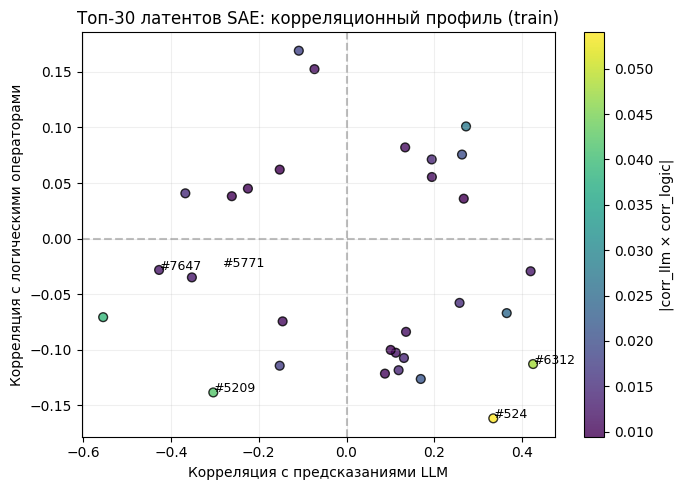

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))
top30 = top_feat[:30]  # top_feat из rank_features_by_logic

sc = ax.scatter(corr_label[top30], corr_logic[top30],
                c=combined[top30], cmap='viridis', s=40, edgecolors='k', alpha=0.8)

ax.set_xlabel('Корреляция с предсказаниями LLM')
ax.set_ylabel('Корреляция с логическими операторами')
ax.set_title('Топ-30 латентов SAE: корреляционный профиль (train)')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Подписываем латенты, которые прошли фильтрацию правил
passed_fids = {r["feature_id"] for r in rules_candidates
                if r["coverage"] >= 0.01 and r["rule_accuracy"] >= 0.60}
for fid in feature_ids[:5]:
    ax.annotate(f'#{fid}', (corr_label[fid], corr_logic[fid]), fontsize=9)

cbar = fig.colorbar(sc, ax=ax, label='|corr_llm × corr_logic|')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

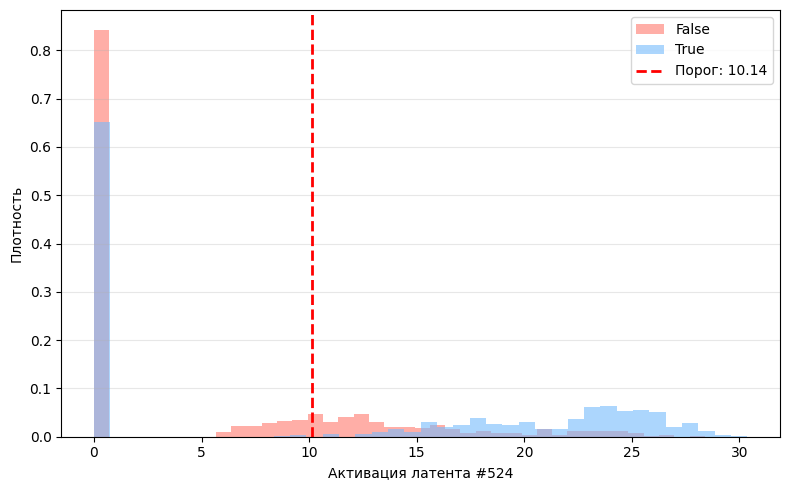

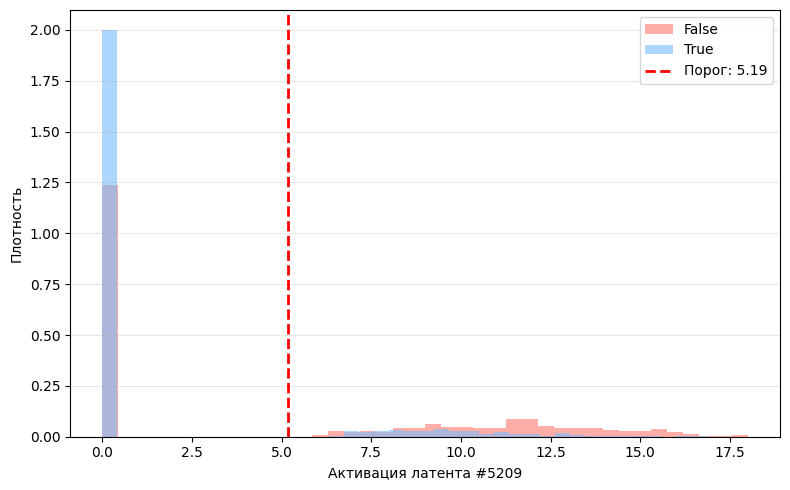

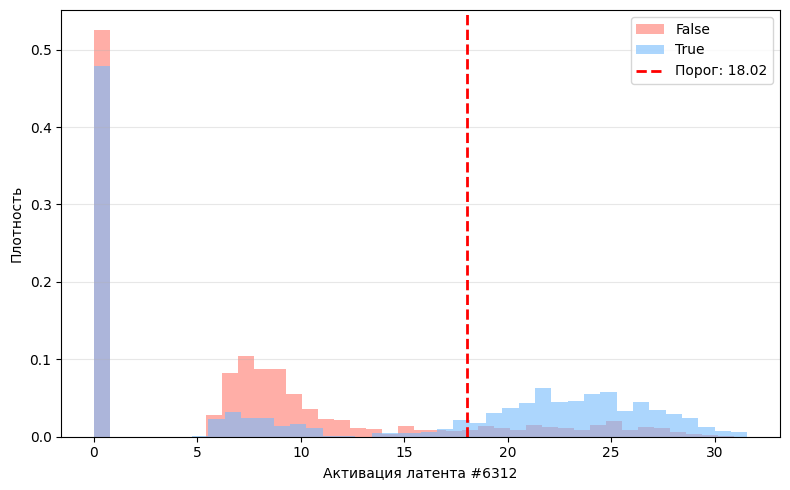

In [30]:
# Гистограммы для топ-3 прошедших правил
for idx, row in passed_rules_df.head(3).iterrows():
    fid, thr = int(row["feature_id"]), row["threshold"]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(activations[labels==0, fid], bins=40, alpha=0.6, label="False", color="xkcd:salmon", density=True)
    ax.hist(activations[labels==1, fid], bins=40, alpha=0.6, label="True", color="xkcd:sky blue", density=True)
    ax.axvline(thr, color="red", linestyle="--", linewidth=2, label=f"Порог: {thr:.2f}")
    ax.set_xlabel(f"Активация латента #{fid}")
    ax.set_ylabel("Плотность")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

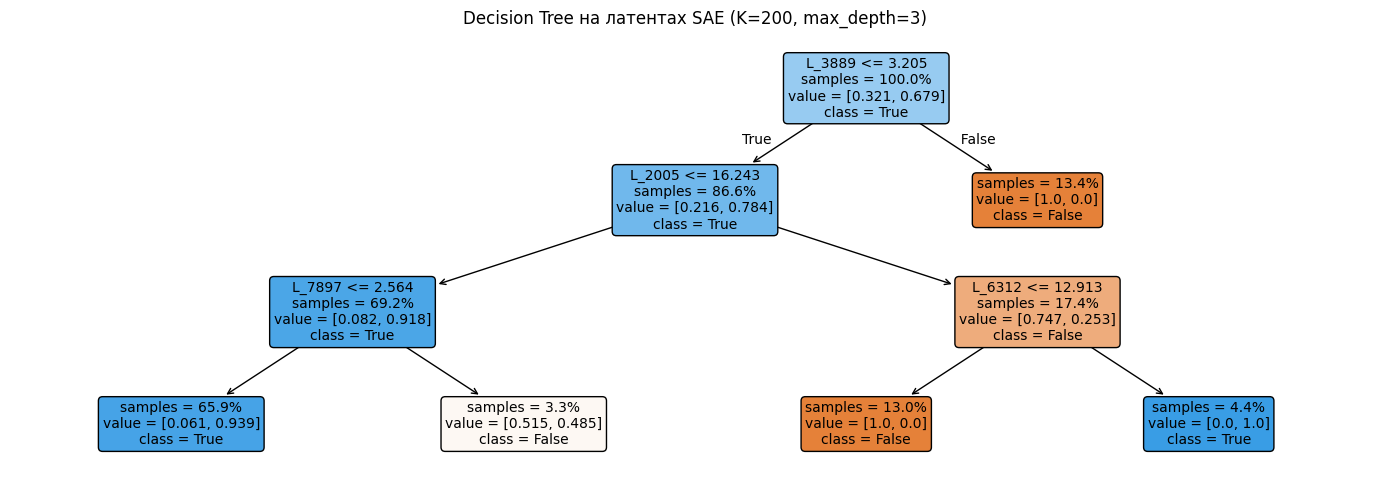

In [31]:
dt_k200 = next((r["model"] for r in sae_dt_results if r["K"] == 200), None)
if dt_k200:
    feat_ids = np.argsort(np.abs(corr_label))[::-1][:200]
    fig, ax = plt.subplots(figsize=(14, 5))
    plot_tree(dt_k200, feature_names=[f"L_{fid}" for fid in feat_ids],
              class_names=["False", "True"], filled=True, rounded=True,
              impurity=False, proportion=True, fontsize=10, ax=ax)
    ax.set_title("Decision Tree на латентах SAE (K=200, max_depth=3)")
    plt.tight_layout()
    plt.show()

In [32]:
# Кривая насыщения и RuleFit (test)
# Сортировка правил для кривой по покрытию (на train), оценка на test
rules_sorted = sorted(rules_candidates, key=lambda r: r["coverage"], reverse=True)
passed_sorted = [r for r in rules_sorted if r["coverage"] >= 0.01 and r["rule_accuracy"] >= 0.60]

In [33]:
coverages = []
explained = np.zeros(len(act_te), dtype=bool)
for i, r in enumerate(passed_sorted, 1):
    preds = (act_te[:, r["feature_id"]] > r["threshold"]).astype(int)
    if r["corr_with_label"] <= 0:
        preds = 1 - preds
    explained |= (preds == llm_te)
    coverages.append((i, float(np.mean(explained))))

sat_95 = next((k for k, cov in coverages if cov >= 0.95), None)
print(f"95% покрытие на test достигается при {sat_95} правилах")

95% покрытие на test достигается при 3 правилах


In [34]:
coverages[:3]

[(1, 0.571), (2, 0.633), (3, 0.996)]

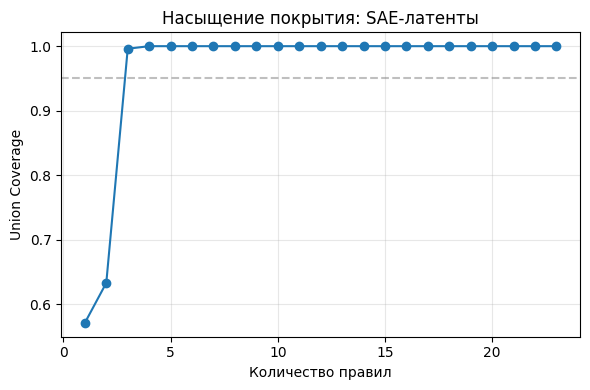

In [35]:
x, y = zip(*coverages)
plt.figure(figsize=(6, 4))
plt.plot(x, y, marker='o')
plt.axhline(0.95, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Количество правил")
plt.ylabel("Union Coverage")
plt.title("Насыщение покрытия: SAE-латенты")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
feat_ids_rf = [r["feature_id"] for r in passed_sorted]
rf = RuleFit(tree_size=4, sample_fract=0.7, max_rules=2000, memory_par=0.5,
                rfmode="classify", lin_trim_quantile=0.025, lin_standardise=True, random_state=42)
rf.fit(act_tr[:, feat_ids_rf], llm_tr)
rf_preds = rf.predict(act_te[:, feat_ids_rf])
print(f"RuleFit | Fidelity vs LLM: {np.mean(rf_preds == llm_te):.4f} | Accuracy vs GT: {np.mean(rf_preds == labels_te):.4f}")

rf_rules = rf.get_rules()
rf_active = rf_rules[rf_rules.coef != 0].sort_values("support", ascending=False)
display(rf_active[["rule", "support", "coef"]].head(10).round(3))

c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\MyPythonProjects\mephi_diss\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attribut

RuleFit | Fidelity vs LLM: 0.9730 | Accuracy vs GT: 0.7940


,rule,support,coef
0,feature_0,1.0,0.003
12,feature_12,1.0,0.137
1,feature_1,1.0,0.001
21,feature_21,1.0,0.012
19,feature_19,1.0,-0.102
18,feature_18,1.0,0.064
17,feature_17,1.0,0.009
16,feature_16,1.0,0.044
15,feature_15,1.0,-0.025
14,feature_14,1.0,0.001


In [37]:
fid_map = {f"feature_{i}": f"Latent_{feat_ids_rf[i]}" for i in range(len(feat_ids_rf))}
rf_active = rf_active.rename(index=fid_map)

is_linear = ~rf_active["rule"].str.contains("<=") & ~rf_active["rule"].str.contains(" and ")
rf_tree_rules = rf_active[~is_linear].sort_values("support", ascending=False).head(10)
rf_lin_rules = rf_active[is_linear].sort_values(by="coef", key=lambda x: x.abs(), ascending=False).head(5)

In [38]:
print("Топ-10 нелинейных правил (основной сигнал):")
display(rf_tree_rules[["rule", "support", "coef"]].round(3))

Топ-10 нелинейных правил (основной сигнал):


,rule,support,coef
191,feature_14 <= 6.892050743103027,0.997,0.051
639,feature_14 <= 6.902405023574829,0.997,0.031
565,feature_16 <= 6.690541982650757,0.997,-0.008
1871,feature_8 <= 23.22468090057373,0.997,-0.001
83,feature_8 <= 23.569722175598145,0.997,-0.023
1112,feature_22 <= 6.010453224182129,0.997,0.004
1027,feature_15 <= 6.98407506942749,0.997,-0.014
992,feature_20 <= 6.5676984786987305,0.997,-0.059
1714,feature_22 <= 6.612761497497559,0.997,-0.021
1716,feature_14 <= 6.967304706573486,0.997,0.043


In [39]:
print("Топ-5 линейных членов (регуляризованы к ~0):")
display(rf_lin_rules[["rule", "support", "coef"]].round(3))

Топ-5 линейных членов (регуляризованы к ~0):


,rule,support,coef
1595,feature_11 > 3.281843900680542,0.131,-5.333
183,feature_5 > 3.204289436340332 & feature_2 > 11...,0.076,-4.113
783,feature_1 > 9.740233898162842 & feature_14 > 5...,0.021,3.543
316,feature_8 > 12.787198066711426 & feature_21 > ...,0.003,3.275
776,feature_11 > 3.516521453857422,0.149,-2.912


# Семантическая аннотация и атрибуции

In [40]:
feat_ids_annot = list({int(best_rule_info["feature_id"])} | set(np.argsort(np.abs(corr_label))[::-1][:3].tolist()))
annotations = extract_semantic_annotations(activations, full_test, tokenizer, feat_ids_annot[:3], top_k=10)
for ann in annotations:
    print(f"Латент #{ann['feature_id']} | Топ-токены: {[t[0] for t in ann['top_tokens'][:10]]}")

Латент #6312 | Топ-токены: ['.', 'is', 'dave', 'bob', 'rough', 'kind', 'gary', 'are', 'red', 'green']
Латент #3889 | Топ-токены: ['is', '.', 'anne', 'charlie', 'fiona', 'not', 'round', 'if', 'then', 'quiet']
Латент #7647 | Топ-токены: ['the', '.', 'is', 'rabbit', 'mouse', 'lion', 'not', 'cat', 'cow', 'sees']


In [41]:
def compare_attributions(latent_idx, example_idx, steps_ig=50):
    text = full_test[example_idx]["text"]
    true_label = bool(full_test[example_idx]["label"])
    tokens_tensor = hooked_model.to_tokens([text], prepend_bos=True).to("cuda")
    raw_tokens = tokenizer.convert_ids_to_tokens(tokens_tensor[0])
    tokens = [t.replace('Ġ', '') if t != 'Ġ' else t for t in raw_tokens]

    with torch.no_grad():
        _, cache = hooked_model.run_with_cache(tokens_tensor, names_filter=lambda n: f"blocks.{BEST_LAYER}.attn.hook_pattern" in n)
    attn_scores = cache[f"blocks.{BEST_LAYER}.attn.hook_pattern"][0, :, -1, :].mean(dim=0).cpu().numpy()

    true_id = int(tokenizer.encode("True", add_special_tokens=False)[-1])
    embeds = hooked_model.embed(tokens_tensor).clone().detach().requires_grad_(True)

    def embed_hook(act, hook):
        return embeds

    logits_sal = hooked_model.run_with_hooks(tokens_tensor, fwd_hooks=[("hook_embed", embed_hook)])
    logits_sal[0, -1, true_id].float().backward()
    saliency_scores = np.linalg.norm(embeds.grad.cpu().float().numpy()[0], axis=-1)

    _, ig_scores = integrated_gradients_latent(hooked_model, sae, tokenizer, text, BEST_LAYER, latent_idx, steps_ig)

    min_len = min(len(tokens), len(attn_scores), len(saliency_scores), len(ig_scores))
    tokens, attn_scores, saliency_scores, ig_scores = (arr[:min_len] for arr in [tokens, attn_scores, saliency_scores, ig_scores])

    with torch.no_grad():
        logits = hooked_model(tokens_tensor)
    false_id = int(tokenizer.encode("False", add_special_tokens=False)[-1])
    pred_str = "True" if logits[0, -1, true_id] > logits[0, -1, false_id] else "False"
    match_str = "совпадает" if (pred_str == "True") == true_label else "не совпадает"
    label_str = "True" if true_label else "False"

    print(f"Example #{example_idx} | Latent #{latent_idx} | GT: {label_str} | Model: {pred_str} ({match_str})")
    visualize_token_attributions(tokens, attn_scores, "Attention (Layer 13)", "YlOrRd", False)
    visualize_token_attributions(tokens, saliency_scores, "Gradient Saliency", "YlOrRd", False)
    visualize_token_attributions(tokens, ig_scores, f"IG (Latent #{latent_idx})", "coolwarm", True)

# Пример 1

In [42]:
fid = best_rule_info["feature_id"]
top_idx = np.argsort(activations[:, fid])[::-1][0]
compare_attributions(latent_idx=fid, example_idx=int(top_idx))

IG для латента 3889: 100%|██████████| 50/50 [00:09<00:00,  5.18it/s]

Example #538 | Latent #3889 | GT: False | Model: False (совпадает)


In [44]:
feature_ids[1]

5209

In [48]:
fid = feature_ids[1]
feat_ids_annot = list({fid} | set(np.argsort(np.abs(corr_label))[::-1][:3].tolist()))
annotations = extract_semantic_annotations(activations, full_test, tokenizer, feat_ids_annot, top_k=10)
for ann in annotations:
    print(f"Латент #{ann['feature_id']} | Топ-токены: {[t[0] for t in ann['top_tokens'][:10]]}")

Латент #6312 | Топ-токены: ['.', 'is', 'dave', 'bob', 'rough', 'kind', 'gary', 'are', 'red', 'green']
Латент #5209 | Топ-токены: ['.', 'is', 'white', 'fiona', 'bob', 'dave', 'smart', 'gary', 'big', 'round']
Латент #7647 | Топ-токены: ['the', '.', 'is', 'rabbit', 'mouse', 'lion', 'not', 'cat', 'cow', 'sees']
Латент #3889 | Топ-токены: ['is', '.', 'anne', 'charlie', 'fiona', 'not', 'round', 'if', 'then', 'quiet']


In [49]:
top_idx = np.argsort(activations[:, fid])[::-1][0]
compare_attributions(latent_idx=fid, example_idx=int(top_idx))

IG для латента 5209: 100%|██████████| 50/50 [00:08<00:00,  5.57it/s]


Example #614 | Latent #5209 | GT: False | Model: False (совпадает)
